IRIS FLOWER CLASSIFICATION

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

Load Dataset

In [2]:
df = pd.read_csv("IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Dataset Information

In [3]:
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape : (150, 5)

Columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


Data Cleaning

Remove duplicate rows

In [4]:
df = df.drop_duplicates()

Check missing values again

In [5]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


Data Visualization

In [6]:
sns.set_style("whitegrid")

Species Count

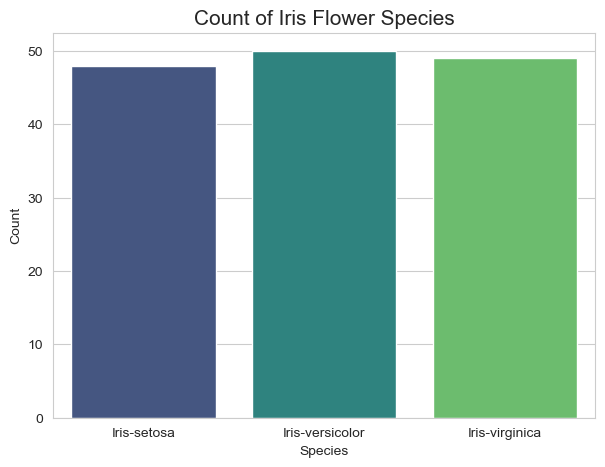

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='species',
    hue='species',
    data=df,
    palette='viridis',
    legend=False
)

plt.title("Count of Iris Flower Species", fontsize=15)
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

Pairplot

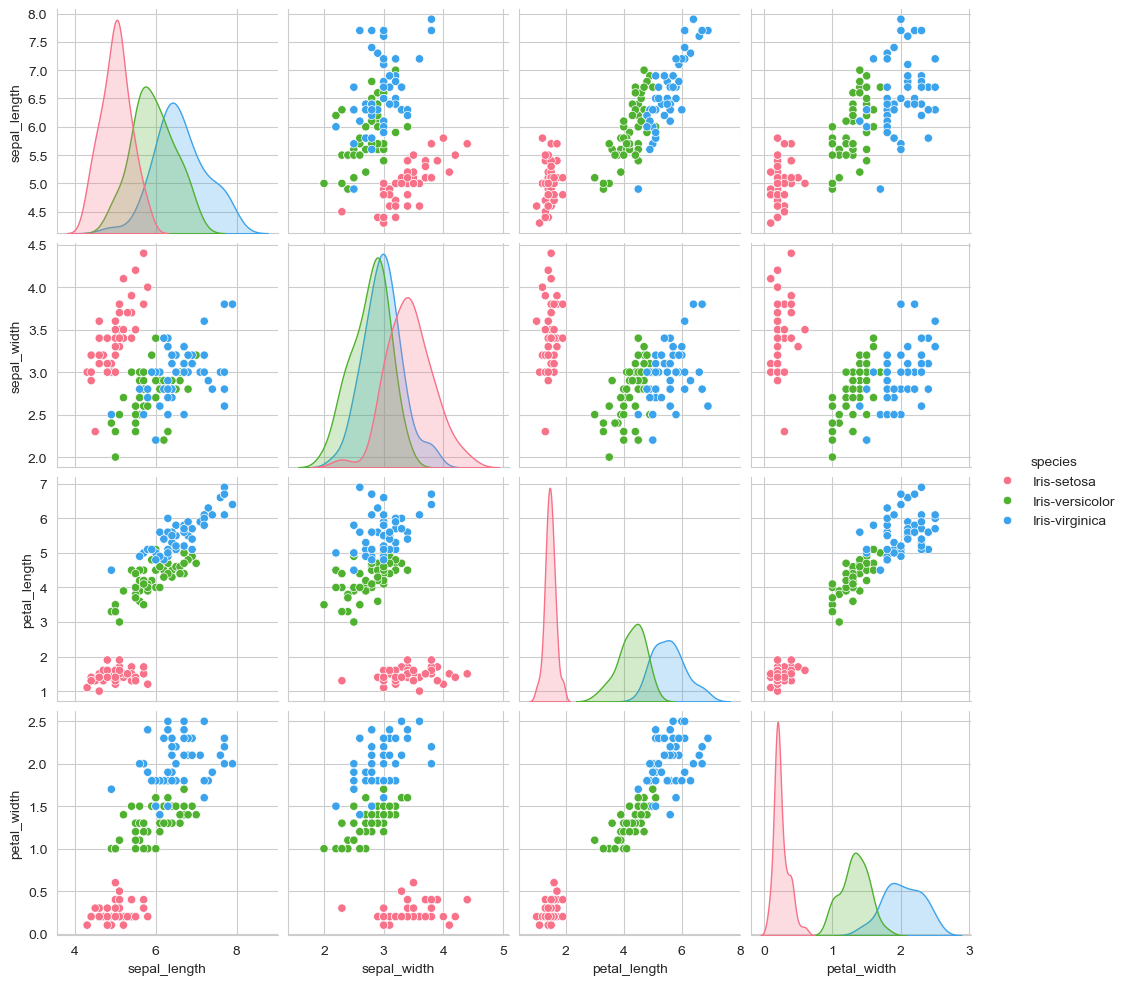

In [8]:
sns.pairplot(df, hue='species', palette='husl')
plt.show()

Heatmap

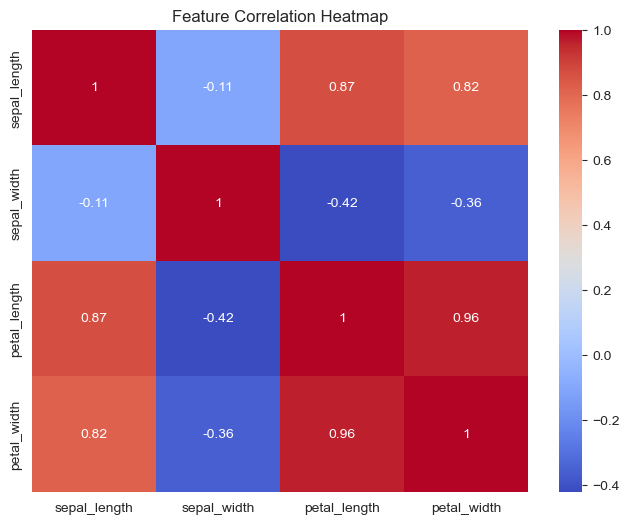

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(df.drop('species', axis=1).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

 Feature Engineering

Encode target column

In [10]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

Define Features and Target

In [11]:
X = df.drop('species', axis=1)
y = df['species']

Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape : (117, 4)
Testing Shape : (30, 4)


Model Training

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


Prediction

In [14]:
y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)


Predicted Values:
[2 1 2 0 1 0 1 0 2 0 0 1 2 1 2 1 0 1 2 0 0 2 0 2 1 0 1 2 1 0]


Model Evaluation

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy Score : 0.9333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Confusion Matrix Visualization

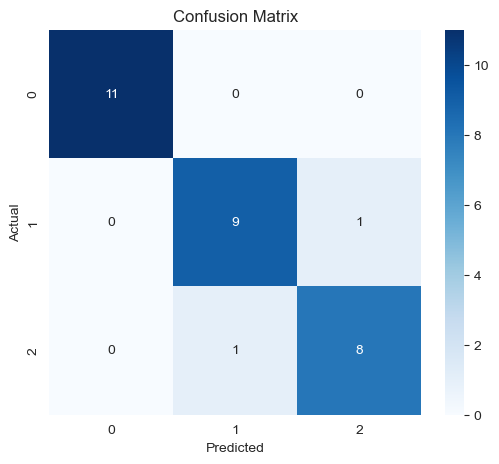

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Sample Prediction

In [17]:
sample_input = pd.DataFrame({
    'sepal_length': [5.1],
    'sepal_width': [3.5],
    'petal_length': [1.4],
    'petal_width': [0.2]
})

sample_prediction = model.predict(sample_input)

predicted_species = le.inverse_transform(sample_prediction)

print("\nPredicted Species :", predicted_species[0])


Predicted Species : Iris-setosa
